# 04 — From-Scratch Dual EncodersRandom-init dual encoders trained end-to-end on Flickr30k (~29 K image–caption pairs). Two image encoders × two tokenizers:| Image | Text | Tokenizer || --- | --- | --- || ViT (small) | Transformer | word, BPE || ResNet18 | Bi-LSTM | word, BPE |The 60+ R@1 gap to CLIP zero-shot quantifies the value of large-scale image–text pre-training.

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import get_device, set_seeds

set_seeds(42)
device = get_device()
print(f"Device: {device}")

Device: cuda


In [2]:
import gc
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.config import EMBEDDINGS_DIR, MODELS_DIR, RESULTS_DIR
from src.data import get_all_captions_flat, load_karpathy_splits
from src.evaluation import (
    evaluate_text_to_image,
    load_results,
    print_results_table,
    save_results,
)
from src.scratch_model import (
    build_cnn_dual,
    build_image_transform,
    build_vit_dual,
    count_params,
)
from src.scratch_tokenizer import ClipBPETokenizer, WordTokenizer
from src.training import (
    HardNegativeInfoNCELoss,
    ScratchRetrievalDataset,
    encode_images_scratch,
    encode_texts_scratch,
    finish_wandb,
    get_optimizer,
    get_scheduler,
    init_wandb,
    log_artifact,
    log_summary,
    log_train_step,
    log_val_metrics,
    make_scratch_collate_fn,
    run_validation_scratch,
    save_checkpoint,
    training_step,
)
from src.visualize import plot_recall_comparison, plot_training_curves

splits = load_karpathy_splits()
train_captions, train_gt = get_all_captions_flat(splits["train"])
val_captions, val_gt = get_all_captions_flat(splits["val"])
test_captions, test_gt = get_all_captions_flat(splits["test"])
test_ds = splits["test"]

train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)
print({k: len(v) for k, v in splits.items()})

  train: 29000 images
  val: 1014 images
  test: 1000 images


{'train': 29000, 'val': 1014, 'test': 1000}


## 2. ViT + Transformer (word & BPE)

In [3]:
train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)

# Sanity check shape on one image; should be (3, 224, 224) float32 with values
# roughly in [-2.1, 2.6] after ImageNet normalization.
sample_pixels = eval_transform(splits["test"][0]["image"].convert("RGB"))
print(f"image tensor shape: {tuple(sample_pixels.shape)}, dtype: {sample_pixels.dtype}, "
      f"min/max: {sample_pixels.min().item():.2f}/{sample_pixels.max().item():.2f}")


image tensor shape: (3, 224, 224), dtype: torch.float32, min/max: -2.12/2.64


In [4]:
TOKENIZER_VARIANTS = ["word", "bpe"]
NUM_EPOCHS = int(os.environ.get("EPOCH_OVERRIDE", "30"))

# Larger batch -> more in-batch contrastive negatives -> stronger signal.
# 5090 has 32 GB; ViT-S + AMP comfortably handles BS=256. Override via env.
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "512" if device.type == "cuda" else "64"))

LR = 0.0005
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
JOINT_DIM = 256
ARCH_TAG = "vit"

# DataLoader parallelism. Pectra has 48 cores -> 12 workers is a safe default
# that keeps the 5090 fed without saturating CPU. prefetch_factor=4 means each
# worker queues 4 batches ahead, so by the time the GPU finishes a step the
# next batch is already collated and pinned.
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

# bfloat16 has the same dynamic range as fp32, so AMP is robust without a
# GradScaler. Blackwell (5090) has native bf16 tensor cores.
AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"

print(
    f"NUM_EPOCHS={NUM_EPOCHS} BATCH_SIZE={BATCH_SIZE} LR={LR} "
    f"WEIGHT_DECAY={WEIGHT_DECAY} WARMUP_RATIO={WARMUP_RATIO}\n"
    f"NUM_WORKERS={NUM_WORKERS} PREFETCH_FACTOR={PREFETCH_FACTOR} "
    f"AMP={USE_AMP} ({AMP_DTYPE})"
)


NUM_EPOCHS=30 BATCH_SIZE=256 LR=0.0005 WEIGHT_DECAY=0.05 WARMUP_RATIO=0.1
NUM_WORKERS=12 PREFETCH_FACTOR=4 AMP=True (torch.bfloat16)


In [5]:
RUN_TRAINING = True

results_per_variant: dict[str, dict] = {}
history_per_variant: dict[str, dict] = {}

if RUN_TRAINING:
    for tok_name in TOKENIZER_VARIANTS:
        run_name = f"scratch_{ARCH_TAG}_{tok_name}"
        print(f"\n{'='*70}\n>>> Variant: {run_name}\n{'='*70}")

        # --- (a) Tokenizer ---
        if tok_name == "word":
            tokenizer = WordTokenizer.from_train_captions(train_captions, max_length=32)
            print(f"WordTokenizer vocab_size={tokenizer.vocab_size}, "
                  f"unk_rate(val)={tokenizer.unk_rate(val_captions):.4f}")
        else:
            tokenizer = ClipBPETokenizer(max_length=32)
            print(f"ClipBPETokenizer vocab_size={tokenizer.vocab_size}")

        # --- (b) Model ---
        model = build_vit_dual(
            vocab_size=tokenizer.vocab_size,
            max_length=tokenizer.max_length,
            pad_token_id=tokenizer.pad_token_id,
            joint_dim=JOINT_DIM,
        ).to(device)
        n_params = count_params(model)
        print(f"Model parameters: {n_params:,}")

        # --- (c) Data pipeline ---
        train_dataset = ScratchRetrievalDataset(splits["train"], image_transform=train_transform)
        loader_kwargs = dict(
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=make_scratch_collate_fn(tokenizer),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
            drop_last=True,
        )
        if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
            loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        train_loader = DataLoader(train_dataset, **loader_kwargs)
        steps_per_epoch = len(train_loader)
        total_steps = steps_per_epoch * NUM_EPOCHS
        print(f"Batches/epoch: {steps_per_epoch}, total steps: {total_steps}")

        # --- (d) Loss / optimizer / scheduler ---
        # No GradScaler: bf16 has fp32-equivalent dynamic range.
        loss_fn = HardNegativeInfoNCELoss(temperature=0.07)
        optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_scheduler(optimizer, total_steps, warmup_ratio=WARMUP_RATIO)

        # --- (e) Save dir + tokenizer ---
        save_dir = MODELS_DIR / run_name
        save_dir.mkdir(parents=True, exist_ok=True)
        tokenizer.save(save_dir)  # so the app can rehydrate later

        # --- (f) WandB ---
        run = init_wandb(
            run_name=run_name,
            config={
                "approach": "scratch",
                "architecture": ARCH_TAG,
                "tokenizer": tok_name,
                "vocab_size": tokenizer.vocab_size,
                "max_text_length": tokenizer.max_length,
                "joint_dim": JOINT_DIM,
                "trainable_params": n_params,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "num_epochs": NUM_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
                "max_grad_norm": MAX_GRAD_NORM,
                "temperature": 0.07,
                "hard_negative_weight": 2.0,
                "loss": "HardNegativeInfoNCE",
                "amp": device.type == "cuda",
                "num_workers": NUM_WORKERS,
                "seed": 42,
                "device": str(device),
            },
            tags=["scratch", ARCH_TAG, tok_name],
        )
        try:
            import wandb
            wandb.watch(model, log="gradients", log_freq=200)
        except Exception:
            pass

        # --- (g) Inner training loop ---
        best_val_r1 = 0.0
        train_losses: list[float] = []
        val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
        global_step = 0

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_losses: list[float] = []
            ep_start = time.time()
            for batch in train_loader:
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(model, batch, loss_fn, device)

                # bf16 keeps fp32 range, so plain backward + clip + step works
                # without a GradScaler.
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()

                epoch_losses.append(metrics["loss"])
                train_losses.append(metrics["loss"])
                global_step += 1

                log_train_step(
                    {
                        "loss": metrics["loss"],
                        "acc_i2t": metrics["acc_i2t"],
                        "acc_t2i": metrics["acc_t2i"],
                        "lr": scheduler.get_last_lr()[0],
                    },
                    step=global_step,
                )

            avg_loss = float(np.mean(epoch_losses))

            # --- (h) Per-epoch validation ---
            val = run_validation_scratch(
                model,
                tokenizer,
                eval_transform,
                splits["val"],
                val_captions,
                val_gt,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
            )
            for k in ["R@1", "R@5", "R@10"]:
                val_metrics_history[k].append(val[k])

            log_val_metrics({**val, "epoch_loss": avg_loss}, epoch=epoch)
            print(
                f"[{tok_name}] Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: "
                f"loss={avg_loss:.4f} | "
                f"Val R@1={val['R@1']:.3f} R@5={val['R@5']:.3f} R@10={val['R@10']:.3f}",
                flush=True,
            )

            # --- (i) Best-checkpoint save ---
            if val["R@1"] > best_val_r1:
                best_val_r1 = val["R@1"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "epoch": epoch,
                        "val_results": val,
                        "loss": avg_loss,
                    },
                    save_dir / "best.pt",
                )
                print(f"[{tok_name}]   -> New best (R@1={best_val_r1:.3f}); checkpoint saved", flush=True)

        print(f"[{tok_name}] Best val R@1: {best_val_r1:.3f}", flush=True)

        # --- (j) Test-set evaluation (reload best) ---
        ckpt = torch.load(save_dir / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        test_img_emb = encode_images_scratch(
            splits["test"], model, eval_transform, device=device, batch_size=EVAL_BATCH_SIZE
        )
        test_txt_emb = encode_texts_scratch(
            test_captions, model, tokenizer, device=device, batch_size=EVAL_BATCH_SIZE * 2
        )

        np.save(EMBEDDINGS_DIR / f"{run_name}_images_test.npy", test_img_emb)
        np.save(EMBEDDINGS_DIR / f"{run_name}_texts_test.npy", test_txt_emb)
        print(f"[{tok_name}] Cached test embeddings: imgs={test_img_emb.shape} txts={test_txt_emb.shape}")

        test_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
        save_results(test_results, run_name)
        print(f"[{tok_name}] Test results:")
        for k, v in test_results.items():
            print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

        log_summary(test_results, prefix="test")
        log_artifact(save_dir / "best.pt", name=run_name, artifact_type="model")
        finish_wandb()

        results_per_variant[run_name] = test_results
        history_per_variant[run_name] = {
            "train_losses": train_losses,
            "val_metrics_history": val_metrics_history,
        }

        # --- (k) Cleanup between variants ---
        del model, optimizer, scheduler, train_loader, train_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nAll variants done.")



>>> Variant: scratch_vit_word


WordTokenizer vocab_size=9471, unk_rate(val)=0.0089


Model parameters: 6,558,464
Batches/epoch: 113, total steps: 3390


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/students/xvysnya/.netrc.


wandb: Currently logged in as: vysnyandrej (vysnyandrej-slovak-university-of-technology-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▁▁▁▂▂▂▂▂▂▃▂▂▄▃▄▅▄▄▄▅▆▄▆▇▅▇▇█▆▆█▇█▇█▇▆▇▇
wandb: train/acc_t2i ▁▁▁▁▁▂▃▃▂▃▂▃▂▃▃▄▄▄▅▄▄▅▄▅▄▅▅▆▆▅▆▅▆█▆▆█▆▇▇
wandb:    train/loss █▇██▇▆▆▅▅▅▄▅▄▄▄▃▃▃▃▃▃▂▂▃▃▂▃▃▃▂▁▂▂▂▁▂▁▁▁▂
wandb:      train/lr ▄▅▆███▇▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:    test/MeanR 142.8476
wandb:  test/MedianR 58
wandb:      test/R@1 0.0396
wandb:     test/R@10 0.1972
wandb:      test/R@5 0.1234
wandb: train/acc_i2t 0.21875
wandb: train/acc_t2i 0.21094
wandb:    train/loss 3.34
wandb:      train/lr 0
wandb: 


wandb: 🚀 View run scratch_vit_bpe at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/nf2eyzht
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260506_180535-nf2eyzht/logs


wandb: WARNING Tried to log to step 29 that is less than the current step 3390. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.



All variants done.



  Scratch ViT vs CLIP variants
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
scratch_vit_word              3.1%    10.9%    17.4%      68.0     151.7
scratch_vit_bpe               4.0%    12.3%    19.7%      58.0     142.8
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.8%    88.1%    93.4%       1.0       4.7
CLIP B/32 Full FT            68.4%    90.0%    94.4%       1.0       3.9
CLIP B/32 + LoRA (r=8)       67.2%    89.2%    94.2%       1.0       4.1



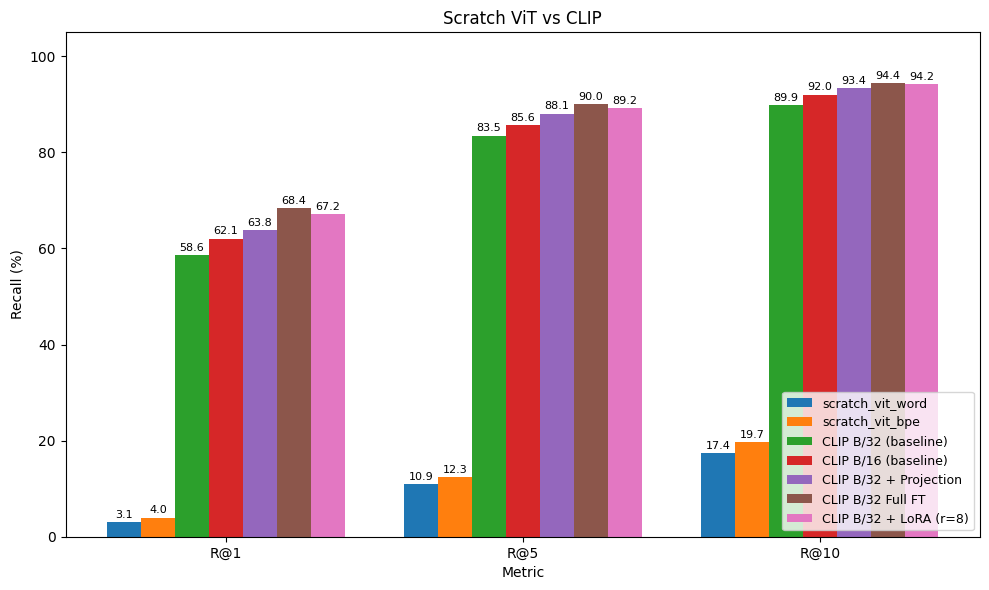

In [6]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    comparison: dict[str, dict] = dict(results_per_variant)

    for display, candidates in [
        ("CLIP B/32 (baseline)", ["baseline_b32", "baseline_clip-vit-b-32"]),
        ("CLIP B/16 (baseline)", ["baseline_b16", "baseline_clip-vit-b-16"]),
        ("CLIP B/32 + Projection", ["projection_head_b32"]),
        ("CLIP B/32 Full FT", ["full_finetune_b32"]),
        ("CLIP B/32 + LoRA (r=8)", ["lora_b32"]),
    ]:
        for fname in candidates:
            try:
                comparison[display] = load_results(fname)
                break
            except FileNotFoundError:
                continue

    print_results_table(comparison, title="Scratch ViT vs CLIP variants")
    plot_recall_comparison(comparison, title="Scratch ViT vs CLIP")


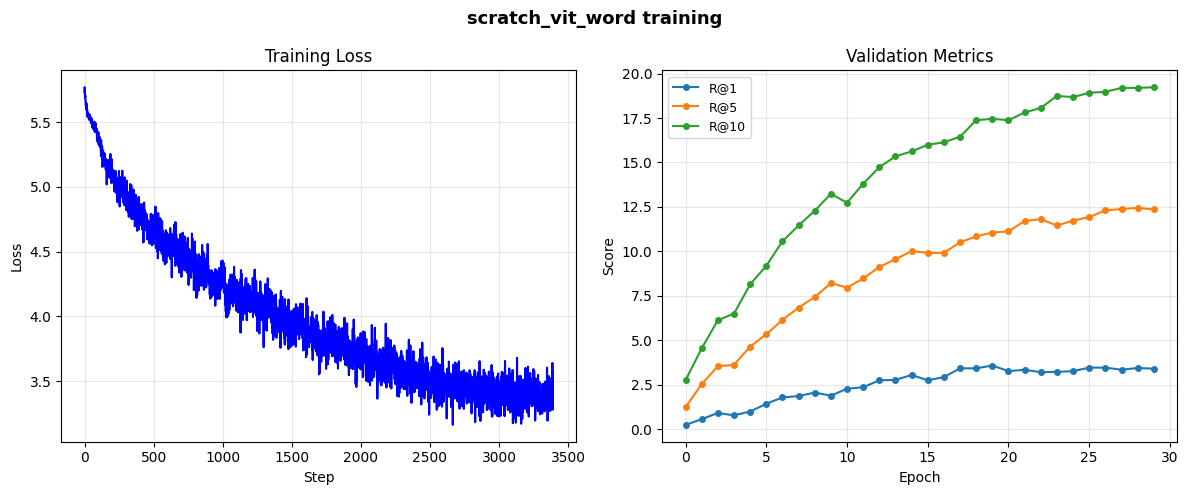

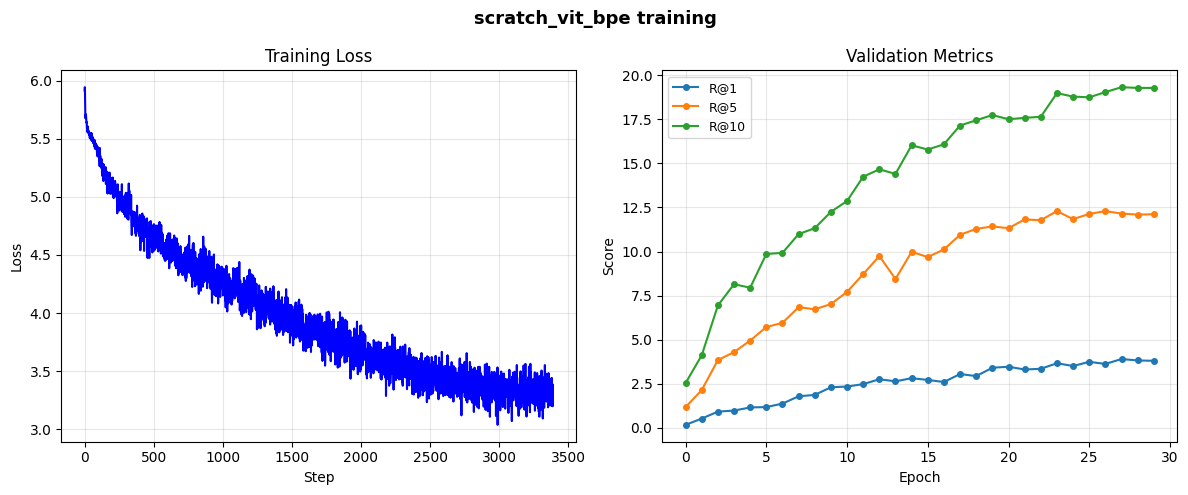

In [7]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    for run_name, hist in history_per_variant.items():
        plot_training_curves(
            hist["train_losses"], hist["val_metrics_history"], title=f"{run_name} training"
        )


## 3. ResNet18 + Bi-LSTM (word & BPE)

In [8]:
train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)

sample_pixels = eval_transform(splits["test"][0]["image"].convert("RGB"))
print(f"image tensor shape: {tuple(sample_pixels.shape)}, dtype: {sample_pixels.dtype}")


image tensor shape: (3, 224, 224), dtype: torch.float32


In [9]:
TOKENIZER_VARIANTS = ["word", "bpe"]
NUM_EPOCHS = int(os.environ.get("EPOCH_OVERRIDE", "30"))

BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "512" if device.type == "cuda" else "64"))

LR = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
JOINT_DIM = 256
ARCH_TAG = "cnn"

NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"

print(
    f"NUM_EPOCHS={NUM_EPOCHS} BATCH_SIZE={BATCH_SIZE} LR={LR} "
    f"WEIGHT_DECAY={WEIGHT_DECAY} WARMUP_RATIO={WARMUP_RATIO}\n"
    f"NUM_WORKERS={NUM_WORKERS} PREFETCH_FACTOR={PREFETCH_FACTOR} "
    f"AMP={USE_AMP} ({AMP_DTYPE})"
)


NUM_EPOCHS=30 BATCH_SIZE=256 LR=0.001 WEIGHT_DECAY=0.0001 WARMUP_RATIO=0.1
NUM_WORKERS=12 PREFETCH_FACTOR=4 AMP=True (torch.bfloat16)


In [10]:
RUN_TRAINING = True

results_per_variant: dict[str, dict] = {}
history_per_variant: dict[str, dict] = {}

if RUN_TRAINING:
    for tok_name in TOKENIZER_VARIANTS:
        run_name = f"scratch_{ARCH_TAG}_{tok_name}"
        print(f"\n{'='*70}\n>>> Variant: {run_name}\n{'='*70}")

        if tok_name == "word":
            tokenizer = WordTokenizer.from_train_captions(train_captions, max_length=32)
            print(f"WordTokenizer vocab_size={tokenizer.vocab_size}, "
                  f"unk_rate(val)={tokenizer.unk_rate(val_captions):.4f}")
        else:
            tokenizer = ClipBPETokenizer(max_length=32)
            print(f"ClipBPETokenizer vocab_size={tokenizer.vocab_size}")

        model = build_cnn_dual(
            vocab_size=tokenizer.vocab_size,
            max_length=tokenizer.max_length,
            pad_token_id=tokenizer.pad_token_id,
            joint_dim=JOINT_DIM,
        ).to(device)
        n_params = count_params(model)
        print(f"Model parameters: {n_params:,}")

        train_dataset = ScratchRetrievalDataset(splits["train"], image_transform=train_transform)
        loader_kwargs = dict(
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=make_scratch_collate_fn(tokenizer),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
            drop_last=True,
        )
        if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
            loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        train_loader = DataLoader(train_dataset, **loader_kwargs)
        steps_per_epoch = len(train_loader)
        total_steps = steps_per_epoch * NUM_EPOCHS
        print(f"Batches/epoch: {steps_per_epoch}, total steps: {total_steps}")

        # No GradScaler -- bf16 keeps fp32 dynamic range.
        loss_fn = HardNegativeInfoNCELoss(temperature=0.07)
        optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_scheduler(optimizer, total_steps, warmup_ratio=WARMUP_RATIO)

        save_dir = MODELS_DIR / run_name
        save_dir.mkdir(parents=True, exist_ok=True)
        tokenizer.save(save_dir)

        run = init_wandb(
            run_name=run_name,
            config={
                "approach": "scratch",
                "architecture": ARCH_TAG,
                "tokenizer": tok_name,
                "vocab_size": tokenizer.vocab_size,
                "max_text_length": tokenizer.max_length,
                "joint_dim": JOINT_DIM,
                "trainable_params": n_params,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "num_epochs": NUM_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
                "max_grad_norm": MAX_GRAD_NORM,
                "temperature": 0.07,
                "hard_negative_weight": 2.0,
                "loss": "HardNegativeInfoNCE",
                "amp": device.type == "cuda",
                "seed": 42,
                "device": str(device),
            },
            tags=["scratch", ARCH_TAG, tok_name],
        )
        try:
            import wandb
            wandb.watch(model, log="gradients", log_freq=200)
        except Exception:
            pass

        best_val_r1 = 0.0
        train_losses: list[float] = []
        val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
        global_step = 0

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_losses: list[float] = []
            ep_start = time.time()
            for batch in train_loader:
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(model, batch, loss_fn, device)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()

                epoch_losses.append(metrics["loss"])
                train_losses.append(metrics["loss"])
                global_step += 1

                log_train_step(
                    {
                        "loss": metrics["loss"],
                        "acc_i2t": metrics["acc_i2t"],
                        "acc_t2i": metrics["acc_t2i"],
                        "lr": scheduler.get_last_lr()[0],
                    },
                    step=global_step,
                )

            avg_loss = float(np.mean(epoch_losses))

            val = run_validation_scratch(
                model,
                tokenizer,
                eval_transform,
                splits["val"],
                val_captions,
                val_gt,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
            )
            for k in ["R@1", "R@5", "R@10"]:
                val_metrics_history[k].append(val[k])

            log_val_metrics({**val, "epoch_loss": avg_loss}, epoch=epoch)
            print(
                f"[{tok_name}] Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: "
                f"loss={avg_loss:.4f} | "
                f"Val R@1={val['R@1']:.3f} R@5={val['R@5']:.3f} R@10={val['R@10']:.3f}",
                flush=True,
            )

            if val["R@1"] > best_val_r1:
                best_val_r1 = val["R@1"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "epoch": epoch,
                        "val_results": val,
                        "loss": avg_loss,
                    },
                    save_dir / "best.pt",
                )
                print(f"[{tok_name}]   -> New best (R@1={best_val_r1:.3f}); checkpoint saved")

        print(f"[{tok_name}] Best val R@1: {best_val_r1:.3f}")

        ckpt = torch.load(save_dir / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        test_img_emb = encode_images_scratch(
            splits["test"], model, eval_transform, device=device, batch_size=EVAL_BATCH_SIZE
        )
        test_txt_emb = encode_texts_scratch(
            test_captions, model, tokenizer, device=device, batch_size=EVAL_BATCH_SIZE * 2
        )

        np.save(EMBEDDINGS_DIR / f"{run_name}_images_test.npy", test_img_emb)
        np.save(EMBEDDINGS_DIR / f"{run_name}_texts_test.npy", test_txt_emb)
        print(f"[{tok_name}] Cached test embeddings: imgs={test_img_emb.shape} txts={test_txt_emb.shape}")

        test_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
        save_results(test_results, run_name)
        print(f"[{tok_name}] Test results:")
        for k, v in test_results.items():
            print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

        log_summary(test_results, prefix="test")
        log_artifact(save_dir / "best.pt", name=run_name, artifact_type="model")
        finish_wandb()

        results_per_variant[run_name] = test_results
        history_per_variant[run_name] = {
            "train_losses": train_losses,
            "val_metrics_history": val_metrics_history,
        }

        del model, optimizer, scheduler, train_loader, train_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nAll variants done.")



>>> Variant: scratch_cnn_word


WordTokenizer vocab_size=9471, unk_rate(val)=0.0089
Model parameters: 16,493,376
Batches/epoch: 113, total steps: 3390


wandb: setting up run ej1ip8lf


wandb: Tracking run with wandb version 0.26.1


wandb: Run data is saved locally in /home/students/xvysnya/Project2/notebooks/wandb/run-20260506_181259-ej1ip8lf
wandb: Run `wandb offline` to turn off syncing.


...

wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▅▆▅▅▅▅▆▆▅▆▆▇▇▆▇█▆▇▇██▇█▇█
wandb: train/acc_t2i ▁▁▁▂▁▂▂▂▂▂▃▄▃▄▄▄▄▄▅▄▅▅▅▅▆▆▅▆▆▆▇▇▇▆▆▇█▇██
wandb:    train/loss ███▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁
wandb:      train/lr ▂▃▃▃▆█████████▇▇▇▇▇▇▆▆▅▅▅▅▅▄▄▄▃▃▃▃▃▂▂▁▁▁
wandb: 
wandb: Run summary:
wandb:    test/MeanR 93.9684
wandb:  test/MedianR 33
wandb:      test/R@1 0.0602
wandb:     test/R@10 0.2986
wandb:      test/R@5 0.203
wandb: train/acc_i2t 0.37891
wandb: train/acc_t2i 0.33984
wandb:    train/loss 2.54099
wandb:      train/lr 0
wandb: 


wandb: 🚀 View run scratch_cnn_bpe at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/1lj07o2x
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 4 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260506_182033-1lj07o2x/logs


wandb: WARNING Tried to log to step 29 that is less than the current step 3390. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.



All variants done.



  Scratch CNN vs everything
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
scratch_cnn_word              6.9%    20.8%    30.9%      29.5      92.8
scratch_cnn_bpe               6.0%    20.3%    29.9%      33.0      94.0
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.8%    88.1%    93.4%       1.0       4.7
CLIP B/32 Full FT            68.4%    90.0%    94.4%       1.0       3.9
CLIP B/32 + LoRA (r=8)       67.2%    89.2%    94.2%       1.0       4.1
Scratch ViT (word)            3.1%    10.9%    17.4%      68.0     151.7
Scratch ViT (BPE)             4.0%    12.3%    19.7%      58.0     142.8



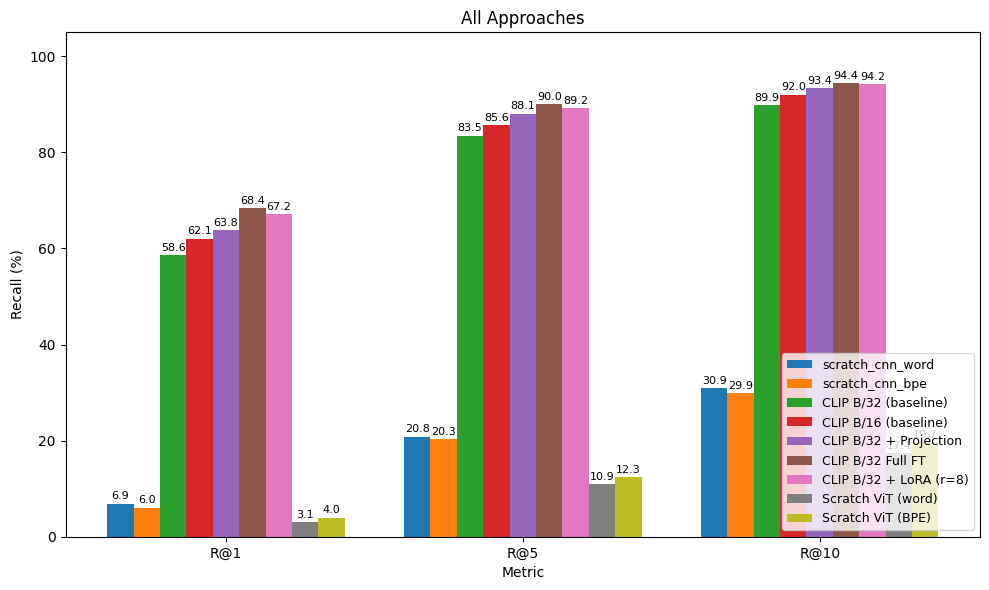

In [11]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    comparison: dict[str, dict] = dict(results_per_variant)

    for display, candidates in [
        ("CLIP B/32 (baseline)", ["baseline_b32", "baseline_clip-vit-b-32"]),
        ("CLIP B/16 (baseline)", ["baseline_b16", "baseline_clip-vit-b-16"]),
        ("CLIP B/32 + Projection", ["projection_head_b32"]),
        ("CLIP B/32 Full FT", ["full_finetune_b32"]),
        ("CLIP B/32 + LoRA (r=8)", ["lora_b32"]),
        ("Scratch ViT (word)", ["scratch_vit_word"]),
        ("Scratch ViT (BPE)", ["scratch_vit_bpe"]),
    ]:
        for fname in candidates:
            try:
                comparison[display] = load_results(fname)
                break
            except FileNotFoundError:
                continue

    print_results_table(comparison, title="Scratch CNN vs everything")
    plot_recall_comparison(comparison, title="All Approaches")


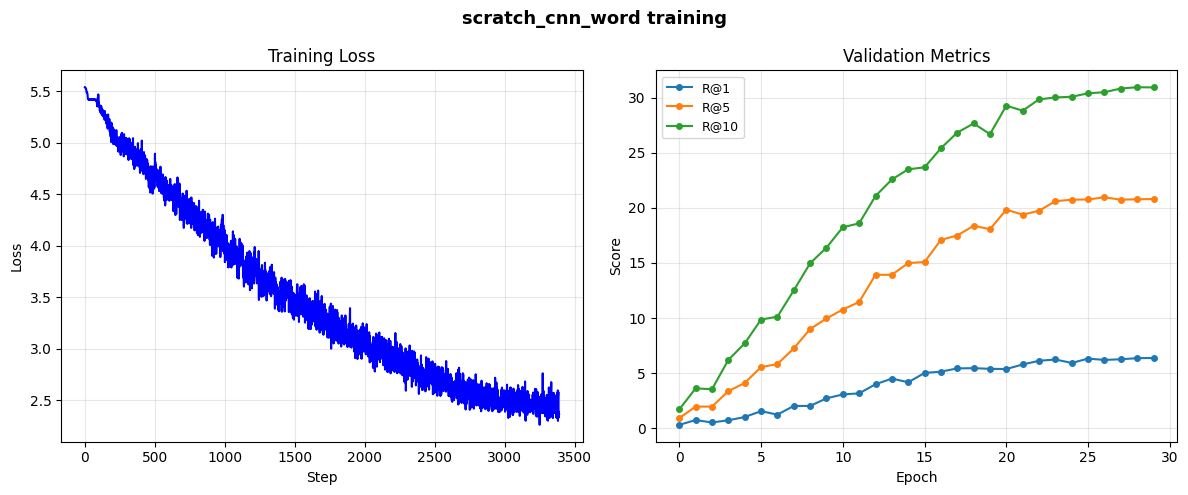

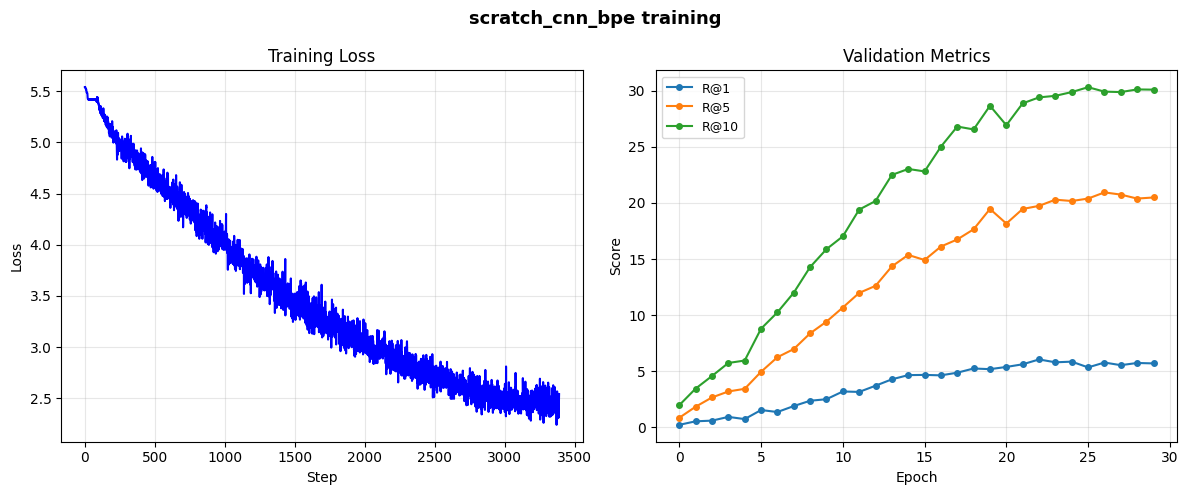

In [12]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    for run_name, hist in history_per_variant.items():
        plot_training_curves(
            hist["train_losses"], hist["val_metrics_history"], title=f"{run_name} training"
        )


## 4. NotesBPE > word for both encoder families; CNN+BiLSTM > ViT+Transformer at this dataset scale (29 K pairs). Best scratch configuration still trails CLIP zero-shot by ~60 R@1 points.